3장 신경망 학습

In [ ]:
# 예제 3.1 단층 신경망 학습(OR 연산)

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(7)

# 학습 데이터 준비
x_train = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])   # 학습 데이터
y_train = torch.tensor([[0.], [1.], [1.], [1.]])   # 레이블(정답)

In [ ]:
# 모델 생성
model = nn.Sequential(
    nn.Linear(2, 1),   # 입력 특징 2개, 출력층 뉴런 1개
    nn.Sigmoid()   # 활성화 함수로 sigmoid 함수 사용
)

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()   # 손실 함수로 MSE 사용
optimizer = optim.SGD(model.parameters(), lr=0.5)   # 옵티마이저로 SGD 사용

In [ ]:
# 모델 학습
epochs =1000
losses = []   # 손실 리스트

for epoch in range(epochs):
    output = model(x_train)   # 출력 계산
    loss = loss_fn(output, y_train)   # 손실 계산

    optimizer.zero_grad()   # 그레디언트 초기화
    loss.backward()   # 역전파(기울기 계산)
    optimizer.step()   # 최적화 수행(파라미터 변경)

    losses.append(loss.item())  # 손실 저장(학습 결과 시각화용)

    if epoch == 0 or (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1} \tLoss: {loss.item():.4f}")

Epoch 1 	Loss: 0.2718
Epoch 100 	Loss: 0.0739
Epoch 200 	Loss: 0.0404
Epoch 300 	Loss: 0.0263
Epoch 400 	Loss: 0.0190
Epoch 500 	Loss: 0.0146
Epoch 600 	Loss: 0.0118
Epoch 700 	Loss: 0.0099
Epoch 800 	Loss: 0.0084
Epoch 900 	Loss: 0.0073
Epoch 1000 	Loss: 0.0065


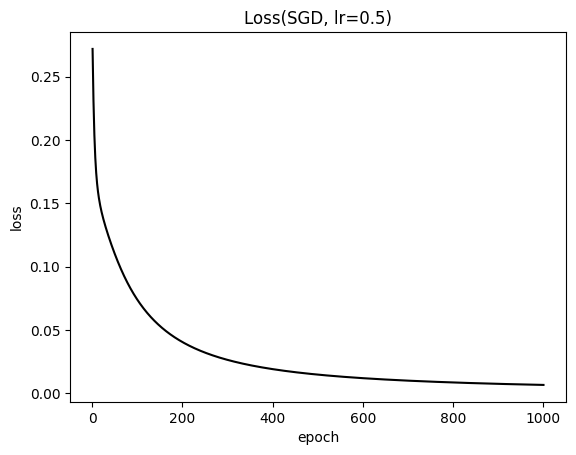

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.title("Loss(SGD, lr=0.5)")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

In [ ]:
# 학습 후 가중치 확인
weights, bias = model.parameters()

w = weights.detach().numpy()   # 연산 그래프에서 분리하고 배열로 변환
b = bias.detach().numpy()

print(f"weights: {w.round(2)} \nbias: {b.round(2)}")

weights: [[4.49 4.49]] 
bias: [-1.98]


In [ ]:
# 모델 예측
x_test = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])   # 테스트 입력
y_test = torch.tensor([[0.], [0.], [0.], [1.]])   # 테스트 정답

threshold = 0.5   # 임계치 0.5

with torch.no_grad():   # 자동 미분하지 않음
    predict = model(x_test)   # 예측
    predict = (predict > threshold).int()   # 정수 출력

    # 예측 결과 확인
    for i in range(4):
        print(f"x: {x_test[i].int().tolist()}   y: {y_test[i].int().tolist()} "
              f"  predict: {predict[i].item()}")

x: [0, 0]   y: [0]   predict: 0
x: [0, 1]   y: [0]   predict: 1
x: [1, 0]   y: [0]   predict: 1
x: [1, 1]   y: [1]   predict: 1


In [ ]:
# 예제 3.2 단층 신경망 학습(AND 연산)

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(7)

# 학습 데이터 준비
x_train = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])   # 학습 데이터
y_train = torch.tensor([[0.], [0.], [0.], [1.]])   # 레이블(정답)

In [ ]:
# 모델 생성
model = nn.Sequential(
    nn.Linear(2, 1),   # 입력 특징 2개, 출력층 뉴런 1개
    nn.Sigmoid()   # 활성화 함수로 sigmoid 함수 사용
)

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()   # 손실 함수로 MSE 사용
optimizer = optim.Adam(model.parameters(), lr=0.5)   # 옵티마이저로 Adam 사용

In [ ]:
# 모델 학습
epochs = 50
losses = []   # 손실 리스트

for epoch in range(epochs):
    output = model(x_train)   # 출력 계산
    loss = loss_fn(output, y_train)   # 손실 계산

    optimizer.zero_grad()   # 그레디언트 초기화
    loss.backward()   # 역전파(기울기 계산)
    optimizer.step()   # 최적화 수행(파라미터 변경)

    losses.append(loss.item())  # 손실 저장(학습 결과 시각화용)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1} \tLoss: {loss.item():.4f}")

Epoch 1 	Loss: 0.2809
Epoch 10 	Loss: 0.0404
Epoch 20 	Loss: 0.0085
Epoch 30 	Loss: 0.0035
Epoch 40 	Loss: 0.0022
Epoch 50 	Loss: 0.0017


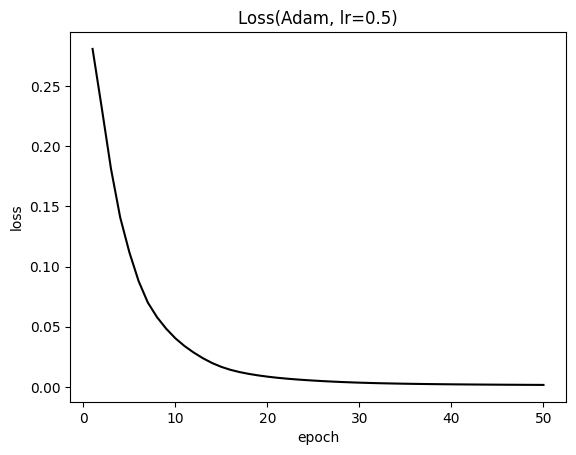

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.title("Loss(Adam, lr=0.5)")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

In [ ]:
# 학습 후 가중치 확인
weights, bias = model.parameters()

w = weights.detach().numpy()   # 연산 그래프에서 분리하고 배열로 변환
b = bias.detach().numpy()

print(f"weights: {w.round(2)} \nbias: {b.round(2)}")

weights: [[6.08 5.98]] 
bias: [-9.06]


In [ ]:
# 모델 예측
x_test = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])   # 테스트 입력
y_test = torch.tensor([[0.], [0.], [0.], [1.]])   # 테스트 정답

threshold = 0.5   # 임계치 0.5

with torch.no_grad():   # 자동 미분하지 않음
    predict = model(x_test)   # 예측
    predict = (predict > threshold).int()   # 정수 출력

    # 예측 결과 확인
    for i in range(4):
        print(f"x: {x_test[i].int().tolist()}   y: {y_test[i].int().tolist()} "
              f"  predict: {predict[i].item()}")

x: [0, 0]   y: [0]   predict: 0
x: [0, 1]   y: [0]   predict: 0
x: [1, 0]   y: [0]   predict: 0
x: [1, 1]   y: [1]   predict: 1


In [ ]:
# 예제 3.3 다층 신경망 학습(XOR 연산)

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(7)

# 학습 데이터 준비
x_train = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])   # 학습 데이터
y_train = torch.tensor([[0.], [1.], [1.], [0.]])   # 레이블(정답)

In [ ]:
# 모델 정의
class XORModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)   # 입력 특징 2개, 은닉층 뉴런 8개
        self.fc2 = nn.Linear(8, 1)   # 출력층 뉴런 1개

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))   # 활성화 함수로 sigmoid 함수 사용
        x = torch.sigmoid(self.fc2(x))
        return x

# 모델 생성
model = XORModel()

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()   # 손실 함수로 MSE 사용
optimizer = optim.Adam(model.parameters(), lr=0.1)   # 옵티마이저로 Adam 사용

In [ ]:
# 모델 학습
epochs = 100
losses = []   # 손실 리스트

for epoch in range(epochs):
    output = model(x_train)   # 출력 계산
    loss = loss_fn(output, y_train)   # 손실 계산

    optimizer.zero_grad()   # 그레디언트 초기화
    loss.backward()   # 역전파(기울기 계산)
    optimizer.step()   # 최적화 수행(파라미터 변경)

    losses.append(loss.item())  # 손실 저장(학습 결과 시각화용)

    if epoch == 0 or (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1} \tLoss: {loss.item():.4f}")

Epoch 1 	Loss: 0.2643
Epoch 20 	Loss: 0.2385
Epoch 40 	Loss: 0.1347
Epoch 60 	Loss: 0.0088
Epoch 80 	Loss: 0.0010
Epoch 100 	Loss: 0.0005


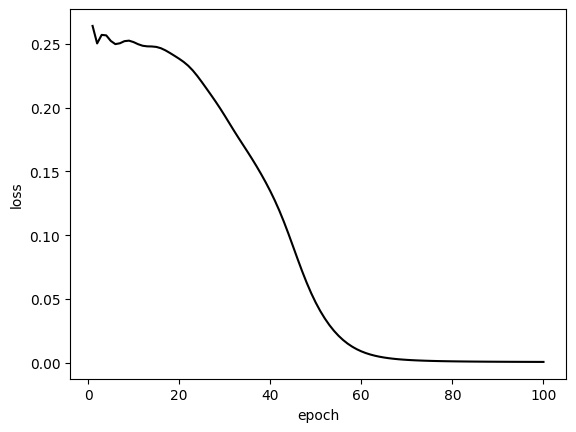

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color='black')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

In [ ]:
# 학습 후 계층별 가중치 확인
for name, param in model.state_dict().items():
    print(name, param.numpy().round(2))

fc1.weight [[-6.1  -6.44]
 [-6.54 -6.44]
 [-4.06 -4.44]
 [-6.67 -6.23]
 [-4.34 -2.96]
 [ 1.88  1.92]
 [-3.49 -4.15]
 [-5.89 -5.92]]
fc1.bias [ 2.4   2.81  5.7   2.51  4.75 -1.95  5.05  2.58]
fc2.weight [[-3.54 -2.83  3.7  -3.97  2.4  -2.8   3.26 -2.11]]
fc2.bias [-1.61]


In [ ]:
# 모델 예측
x_test = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])   # 테스트 입력
y_test = torch.tensor([[0.], [1.], [1.], [0.]])   # 테스트 정답

threshold = 0.5   # 임계치 0.5

with torch.no_grad():   # 자동 미분하지 않음
    predict = model(x_test)   # 예측
    predict = (predict > threshold).int()   # 정수 출력

    # 예측 결과 확인
    for i in range(4):
        print(f"x: {x_test[i].int().tolist()}   y: {y_test[i].int().tolist()} "
              f"  predict: {predict[i].item()}")

x: [0, 0]   y: [0]   predict: 0
x: [0, 1]   y: [1]   predict: 1
x: [1, 0]   y: [1]   predict: 1
x: [1, 1]   y: [0]   predict: 0


In [ ]:
# 예제 3.4 이미지 증강

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 셋업
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

size of image: (1024, 1024)


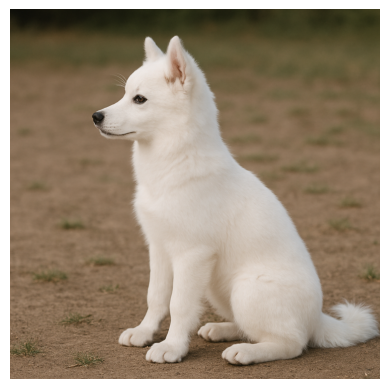

In [ ]:
# 원본 이미지 확인
file_path = "/content/drive/MyDrive/Datasets/강아지 사진.png"

with Image.open(file_path) as img:
    print(f"size of image: {img.size}")

    plt.imshow(img)
    plt.axis("off")

    plt.show()

In [ ]:
# 데이터 증강
image_augment = transforms.Compose([
    transforms.Resize((160, 160)),   # 크기 조정
    transforms.RandomHorizontalFlip(),  # 수평 뒤집기
    transforms.RandomAffine(degrees=15, scale=(1.0, 1.3)),  # 회전(15°)/확대(30%)
    transforms.ToTensor()   # 텐서 변환
])

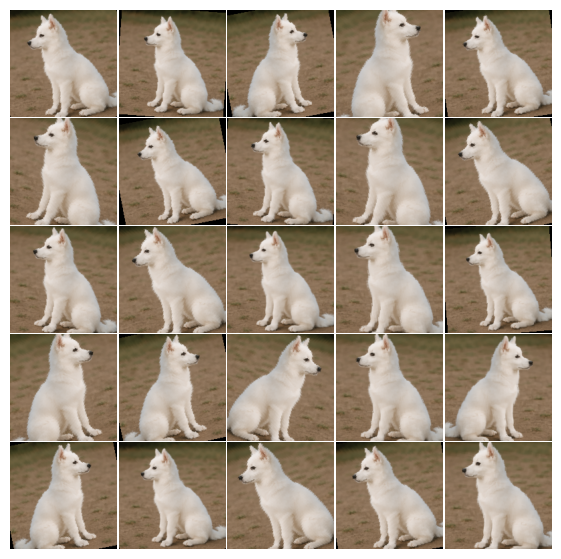

In [ ]:
# 데이터 증강 시각화
plt.figure(figsize=(7, 7))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i in range(25):
    augmented_image = image_augment(img)

    plt.subplot(5, 5, i + 1)
    plt.imshow(augmented_image.permute(1, 2, 0))   # (height, width, channels)
    plt.axis("off")

plt.show()

In [ ]:
# 예제 3.6 성능 평가(이진 분류)

# 셋업
import torch
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 레이블/예측값
y_test = torch.tensor([0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1])
y_pred = torch.tensor([1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1])

In [ ]:
# 배열로 변환
actual = y_test.numpy()
predicted = y_pred.numpy()

In [ ]:
# 혼동 행렬
cm = confusion_matrix(actual, predicted)

print(cm)

[[9 1]
 [2 8]]


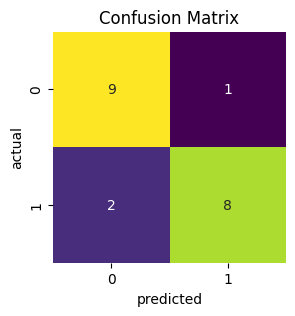

In [ ]:
# 혼동 행렬 시각화
plt.figure(figsize=(3, 3))

sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

In [ ]:
# 정확도 계산
print(f"accuracy: {accuracy_score(actual, predicted):.2f}")

accuracy: 0.85


In [ ]:
# 정밀도, 민감도(재현율) 등의 성능 평가 지표 계산
print(f"precision: {precision_score(actual, predicted):.2f}")
print(f"sensitivity(recall): {recall_score(actual, predicted):.2f}")
print(f"specificity: {recall_score(actual, predicted, pos_label=0):.2f}")
print(f"f1 score: {f1_score(actual, predicted):.2f}")

precision: 0.89
sensitivity(recall): 0.80
specificity: 0.90
f1 score: 0.84


AUC: 0.85


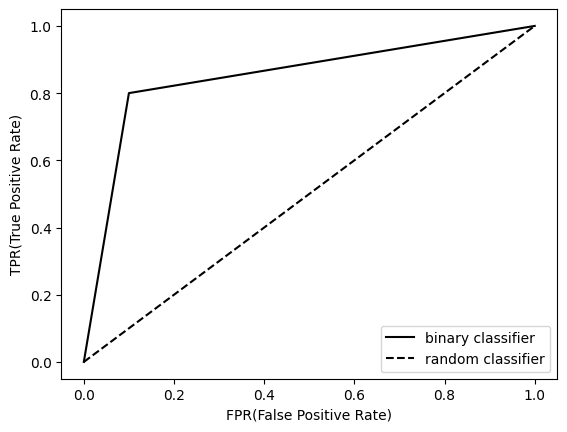

In [ ]:
# ROC 곡선 시각화
print(f"AUC: {roc_auc_score(actual, predicted):.2f}")   # AUC 계산

fpr, tpr, threshold = roc_curve(actual, predicted)   # FPR과 TPR 값 계산

plt.plot(fpr, tpr, label="binary classifier", color="black")   # ROC 곡선
plt.plot([0, 1], [0, 1], label="random classifier", color="black", linestyle="--")
plt.xlabel("FPR(False Positive Rate)")
plt.ylabel("TPR(True Positive Rate)")
plt.legend(loc="lower right")

plt.show()